# Point Operator


Histogram: biểu đồ tần số, thể hiện số lần 1 giá trị (từ 0-255) xuất hiện trong bức ảnh

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img_path = "./Chuot.jpg"
img = cv2.imread(img_path)
# cv2.imshow("Chuot", img)
# cv2.waitKey()

In [2]:
count_red = np.zeros(256)
count_green = np.zeros(256)
count_blue = np.zeros(256)

for i in range(img.shape[0]):
    for j in range(img.shape[1]):
        count_red[img[i, j, 0]] += 1
        count_green[img[i, j, 1]] += 1
        count_blue[img[i, j, 2]] += 1

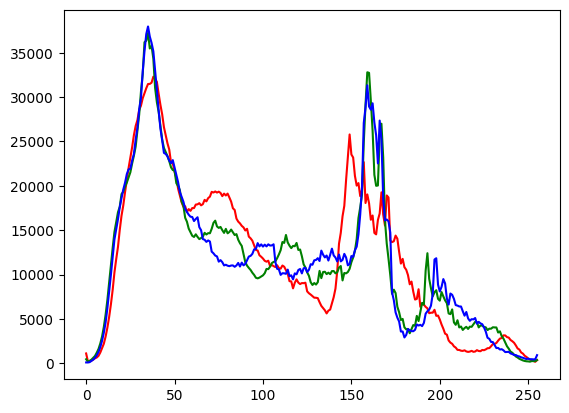

In [3]:
img2 = plt.imread(img_path)
# plt.imshow(img2, extent=[0, 25600, 0, 11830])
# print(img2.shape)
plt.plot(count_red, color="red")
plt.plot(count_green, color="green")
plt.plot(count_blue, color="blue")

chỉnh màu

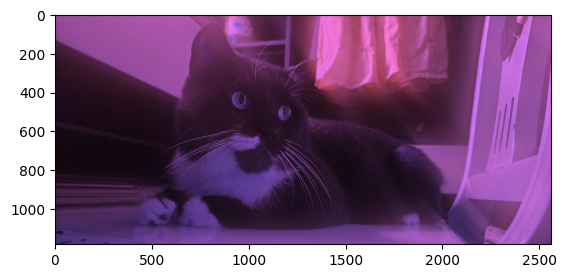

In [4]:
img3 = img.copy()
img3[:, :, 1] = img3[:, :, 1] / 2
plt.imshow(img3)

## Equalize

In [5]:
img4 = cv2.imread('./images/Equalization.png',0)
# cv2.imshow("Chuot", img4)
# cv2.waitKey()
print(img4)

[[249 245 241 ... 240 240 241]
 [245 231 220 ... 220 219 220]
 [242 223 205 ... 206 203 205]
 ...
 [242 223 205 ... 197 199 203]
 [243 224 206 ... 205 203 205]
 [248 240 234 ... 234 234 234]]


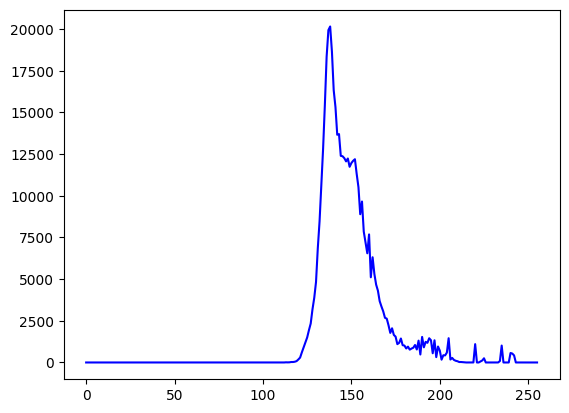

In [6]:
hist = cv2.calcHist([img4], [0], None, [256], [0, 256])
plt.plot(hist, color="blue")

In [7]:
cumulator = np.zeros_like(hist, np.float64)
for i in range(len(hist)):
    cumulator[i] = hist[:i].sum()

# Stretching the histogram
new_hist = (cumulator - cumulator.min()) / (cumulator.max() - cumulator.min()) * 255

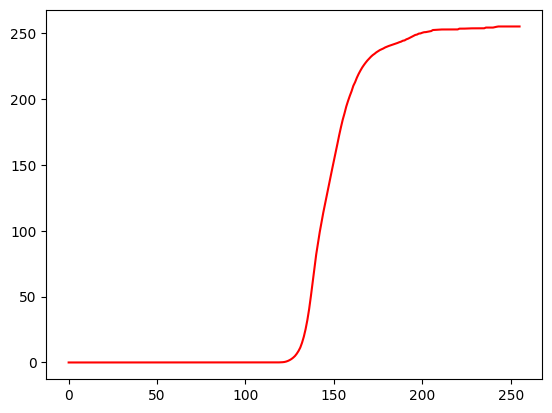

In [8]:
# plt.plot(hist, color="blue")
plt.plot(new_hist, color="red")
# plt.plot(cumulator, color="green")

In [9]:
img_equal = img4.copy()

h, w = img4.shape
for i in range(h):
    for j in range(w):
        img_equal[i, j] = new_hist[img4[i, j]]
# plt.imshow(img_equal)
# plt.show()

# cv2.imshow("original", img4)
# cv2.imshow("img_equal", img_equal)
# cv2.waitKey()

/var/folders/qk/pz9gz5ds2gz27n9rkfdv84_m0000gn/T/ipykernel_13023/2616658802.py:6: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  img_equal[i, j] = new_hist[img4[i, j]]


# Linear Filtering

Dùng Median Filter để lọc nhiễu hạt (kernel vẫn có size như bình thường)

In [10]:
img5 = cv2.imread("./images/salt_and_pepper.png")
# cv2.imshow("salt_and_pepper", img5)
# cv2.waitKey()

mean and median filter

In [11]:
kernel = np.ones((5, 5)) / 25
blurred_img = cv2.filter2D(img5, -1, kernel)
blurred_img2 = cv2.blur(img5, (5, 5))
blurred_img3 = cv2.medianBlur(img5, 5)
blurred_img4 = cv2.medianBlur(img5, 3)
# cv2.imshow("blurred_img", blurred_img)
# cv2.imshow("blurred_img2", blurred_img2)
# cv2.imshow("blurred_img3", blurred_img3)
# cv2.imshow("blurred_img4", blurred_img4)
# cv2.waitKey()

Gaussian Smoothing

In [12]:
blurred_img_gau = cv2.GaussianBlur(img5, (3, 3), 0)
cv2.imshow("blurred_img_gau", blurred_img_gau)
cv2.waitKey()

115

Bilateral Filtering